In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
dataset_path = "../Garbage_Dataset_Classification/images"

print(dataset_path)


../Garbage_Dataset_Classification/images


In [ ]:
classes = os.listdir(dataset_path)

print("Classes:")
for cls in classes:
    print(cls)

Classes:
cardboard
glass
metal
paper
plastic
trash


In [ ]:
import os

print("Dataset folder:")
print(os.listdir("../Garbage_Dataset_Classification"))

print("\nImages folder:")
print(os.listdir("../Garbage_Dataset_Classification/images"))

Dataset folder:
['images', 'metadata.csv']

Images folder:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
for cls in classes:
    class_path = os.path.join(dataset_path, cls)
    images = os.listdir(class_path)
    print(f"{cls}: {len(images)} images")

cardboard: 1436 images
glass: 2500 images
metal: 2084 images
paper: 2315 images
plastic: 2288 images
trash: 2500 images


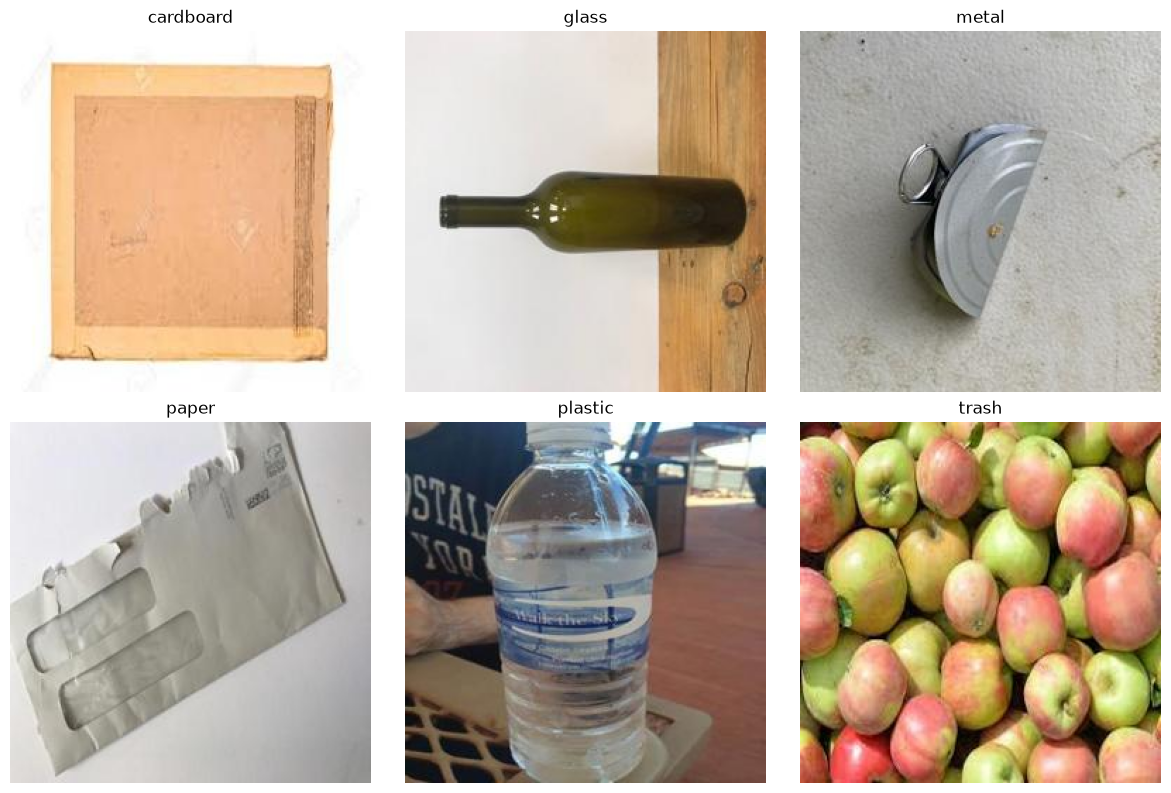

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, cls in zip(axes.flat, classes):
    class_path = os.path.join(dataset_path, cls)
    
    image_file = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_file)
    
    image = Image.open(image_path)
    
    ax.imshow(image)
    ax.set_title(cls)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
sample_image = Image.open(
    os.path.join(
        dataset_path,
        classes[0],
        os.listdir(os.path.join(dataset_path, classes[0]))[0]
    )
)

print("Image size:", sample_image.size)
print("Image mode:", sample_image.mode)

Image size: (256, 256)
Image mode: RGB


In [ ]:
import os
from sklearn.model_selection import train_test_split

dataset_path = "../Garbage_Dataset_Classification/images"

image_paths = []
labels = []

# Collect all image paths and their class labels
for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    if os.path.isdir(class_path):
        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            image_paths.append(image_path)
            labels.append(class_name)

print("Total images:", len(image_paths))
print("Total labels:", len(labels))

Total images: 13123
Total labels: 13123


In [ ]:
from sklearn.model_selection import train_test_split
# First split: 70% training, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# Second split: divide the 30% into 15% validation and 15% testing
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training images:", len(X_train))
print("Validation images:", len(X_val))
print("Testing images:", len(X_test))

Training images: 9186
Validation images: 1968
Testing images: 1969


In [ ]:
from collections import Counter

print("Training distribution:")
print(Counter(y_train))

print("\nValidation distribution:")
print(Counter(y_val))

print("\nTesting distribution:")
print(Counter(y_test))


Training distribution:
Counter({'glass': 1750, 'trash': 1750, 'paper': 1620, 'plastic': 1602, 'metal': 1459, 'cardboard': 1005})

Validation distribution:
Counter({'glass': 375, 'trash': 375, 'paper': 347, 'plastic': 343, 'metal': 312, 'cardboard': 216})

Testing distribution:
Counter({'glass': 375, 'trash': 375, 'paper': 348, 'plastic': 343, 'metal': 313, 'cardboard': 215})


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms


# Class names
class_names = sorted(list(set(labels)))

# Convert class names to numbers
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

print("Class mapping:")
print(class_to_idx)


# Image transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Custom Dataset
class WasteDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):
        image = Image.open(self.image_paths[index]).convert("RGB")
        label = class_to_idx[self.labels[index]]

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = WasteDataset(
    X_train, y_train, train_transform
)

val_dataset = WasteDataset(
    X_val, y_val, val_test_transform
)

test_dataset = WasteDataset(
    X_test, y_test, val_test_transform
)


# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)


print("\nDatasets created successfully!")
print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Class mapping:
{'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}

Datasets created successfully!
Training: 9186
Validation: 1968
Testing: 1969


In [ ]:
# Get one batch of images
images, batch_labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", batch_labels.shape)
print("First 10 labels:", batch_labels[:10])

Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
First 10 labels: tensor([1, 2, 1, 2, 0, 2, 3, 1, 0, 5])


In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained MobileNetV3 Small
model = models.mobilenet_v3_small(
    weights=models.MobileNet_V3_Small_Weights.DEFAULT
)

# Replace the final layer for our 6 waste classes
model.classifier[3] = nn.Linear(
    model.classifier[3].in_features,
    6
)

# Move model to CPU/GPU
model = model.to(device)

print("Model loaded successfully!")
print("Number of classes:", 6)

Using device: cpu
Model loaded successfully!
Number of classes: 6


In [ ]:
import torch.optim as optim
from tqdm import tqdm

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Training setup ready!")

Training setup ready!


In [ ]:
# Trial training: 1 epoch

num_epochs = 1

model.train()

running_loss = 0.0
correct = 0
total = 0

for images, labels_batch in tqdm(train_loader, desc="Training"):
    images = images.to(device)
    labels_batch = labels_batch.to(device)

    # Clear previous gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)

    # Calculate loss
    loss = criterion(outputs, labels_batch)

    # Backpropagation
    loss.backward()

    # Update model weights
    optimizer.step()

    # Statistics
    running_loss += loss.item()

    _, predicted = torch.max(outputs, 1)

    total += labels_batch.size(0)
    correct += (predicted == labels_batch).sum().item()

train_accuracy = 100 * correct / total
average_loss = running_loss / len(train_loader)

print("\nTrial training complete!")
print("Training Loss:", round(average_loss, 4))
print("Training Accuracy:", round(train_accuracy, 2), "%")

Training: 100%|██████████| 575/575 [02:45<00:00,  3.48it/s]


Trial training complete!
Training Loss: 0.6965
Training Accuracy: 75.64 %


In [ ]:
# Validate the model

model.eval()

correct = 0
total = 0
val_loss = 0.0

with torch.no_grad():
    for images, labels_batch in tqdm(val_loader, desc="Validation"):
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels_batch)
        val_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

val_accuracy = 100 * correct / total
average_val_loss = val_loss / len(val_loader)

print("\nValidation complete!")
print("Validation Loss:", round(average_val_loss, 4))
print("Validation Accuracy:", round(val_accuracy, 2), "%")

Validation: 100%|██████████| 123/123 [00:12<00:00, 10.11it/s]


Validation complete!
Validation Loss: 0.7304
Validation Accuracy: 73.58 %


In [18]:
# Continue training up to 5 total epochs

num_epochs = 5

best_val_accuracy = val_accuracy

for epoch in range(2, num_epochs + 1):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    print(f"\nEpoch {epoch}/{num_epochs}")

    for images, labels_batch in tqdm(train_loader, desc="Training"):
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels_batch.size(0)
        correct += (predicted == labels_batch).sum().item()

    train_accuracy = 100 * correct / total
    train_loss = running_loss / len(train_loader)

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels_batch in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels_batch)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels_batch.size(0)
            correct += (predicted == labels_batch).sum().item()

    val_accuracy = 100 * correct / total
    val_loss = val_loss / len(val_loader)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    # -------------------------
    # Save best model
    # -------------------------
    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "../models/wastewise_mobilenetv3_best.pth"
        )

        print("⭐ Best model saved!")

print("\nTraining finished!")
print("Best Validation Accuracy:", round(best_val_accuracy, 2), "%")


Epoch 2/5


Validation: 100%|██████████| 123/123 [00:08<00:00, 15.09it/s]


Train Loss: 0.4559
Train Accuracy: 84.25%
Validation Loss: 0.4539
Validation Accuracy: 86.23%
⭐ Best model saved!

Epoch 3/5


Validation: 100%|██████████| 123/123 [00:09<00:00, 13.06it/s]


Train Loss: 0.3574
Train Accuracy: 88.05%
Validation Loss: 0.4030
Validation Accuracy: 86.18%

Epoch 4/5


Training:  65%|██████▌   | 375/575 [01:49<00:58,  3.44it/s]


KeyboardInterrupt: 

In [ ]:
# Load the best saved model

model.load_state_dict(
    torch.load(
        "../models/wastewise_mobilenetv3_best.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Best model loaded successfully!")

Best model loaded successfully!


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels_batch in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels_batch.cpu().numpy())


# Final test accuracy
test_accuracy = (
    np.array(all_predictions) == np.array(all_true_labels)
).mean() * 100

print("\nTest Accuracy:", round(test_accuracy, 2), "%")

# Detailed classification report
print("\nClassification Report:\n")

print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=class_names
    )
)

Testing: 100%|██████████| 124/124 [00:22<00:00,  5.47it/s]


Test Accuracy: 85.93 %

Classification Report:

              precision    recall  f1-score   support

   cardboard       0.88      0.91      0.90       215
       glass       0.82      0.91      0.87       375
       metal       0.76      0.90      0.83       313
       paper       0.89      0.85      0.87       348
     plastic       0.95      0.72      0.82       343
       trash       0.90      0.88      0.89       375

    accuracy                           0.86      1969
   macro avg       0.87      0.86      0.86      1969
weighted avg       0.87      0.86      0.86      1969



In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
from tqdm import tqdm

model.eval()

all_predictions = []
all_true_labels = []

with torch.no_grad():
    for images, labels_batch in tqdm(test_loader, desc="Testing"):

        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        all_predictions.extend(predicted.cpu().numpy())
        all_true_labels.extend(labels_batch.cpu().numpy())

test_accuracy = (
    np.array(all_predictions) == np.array(all_true_labels)
).mean() * 100

print("Test Accuracy:", round(test_accuracy, 2), "%")

Testing: 100%|██████████| 124/124 [00:10<00:00, 12.28it/s]

Test Accuracy: 87.81 %


<Figure size 800x800 with 0 Axes>

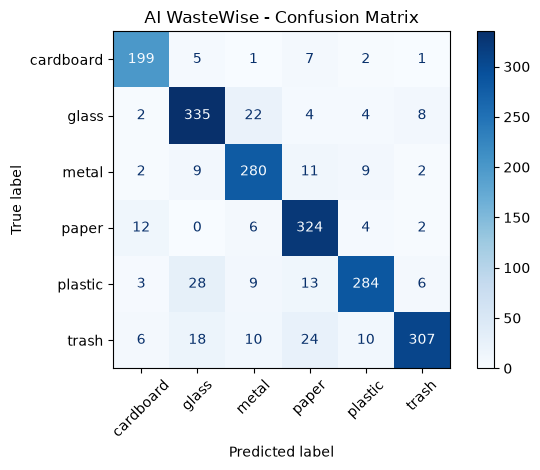

In [21]:
cm = confusion_matrix(
    all_true_labels,
    all_predictions
)

plt.figure(figsize=(8, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=45,
    cmap="Blues"
)

plt.title("AI WasteWise - Confusion Matrix")
plt.tight_layout()
plt.show()